In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import random
import time
import matplotlib.pyplot as plt
import sys

In [4]:
S0 = 100.0      # initial stock price
mu = 0.05     # drift
sigma = 0.15  # volatility
r = 0.03      # risk-free rate
M = 1         # maturity

T = 24        # number of time steps
N_MC = int(1e6)  # number of paths

delta_t = 1. / M                # time interval
lamb = np.exp(- r * delta_t)  # discount factor

sigma_d = sigma / np.sqrt(252)

In [5]:
RN = np.random.randn(N_MC, 1)
S1 = S0 * np.exp((mu - 1/2 * sigma**2) * delta_t + sigma * np.sqrt(delta_t) * RN )

In [6]:
S1a = S0 * (1.0 + sigma_d * RN)

In [32]:
S1a.shape, 1/np.sqrt(1./252.)

((1000000, 1), 15.874507866387543)

In [34]:
# The Black-Scholes prices
def bs_put(t, S0, K, r, sigma, T):
    d1arr = d1(S0, K, r, sigma, T)
    d2arr = d2(S0, K, r, sigma, T)
    price = K * np.exp(-r * (T-t)) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    return price

def bs_call(t, S0, K, r, sigma, T):
    d1 = d1(S0, K, r, sigma, T)
    d2 = d2(S0, K, r, sigma, T)
    price = S0 * norm.cdf(d1) - K * np.exp(-r * (T-t)) * norm.cdf(d2)
    return price

def d1(S0, K, r, sigma, T):
    return (np.log(S0/K) + (r + sigma**2 / 2) * T)/(sigma * np.sqrt(T))
 
def d2(S0, K, r, sigma, T):
    return (np.log(S0 / K) + (r - sigma**2 / 2) * T) / (sigma * np.sqrt(T))

def get_delta_1(S, K, sigma, T):
    stock_prices = S
    return norm.cdf((np.log(stock_prices / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T)))

def opt_delta(S, K, r, sigma, T):
    return norm.cdf(d1(S, K, r, sigma, T))

In [36]:
D0 = opt_delta(S0, 105., r, sigma, 20./252.)
D1 = opt_delta(S1, 105., r, sigma, 19./252)
D1a = opt_delta(S1a, 105., r, sigma, 19./252)

np.nanmean((np.where(S1>S0, D1, np.NaN) - D0) ), np.nanmean((np.where(S1a>S0, D1a, np.NaN) - D0) )

(0.17990495686080066, 0.038506498409659744)

In [27]:
np.nanmean((np.where(S1>S0, D1, np.NaN) - D0) )

0.17990495686080066

In [23]:
np.nanmean((np.where(S1a>S0, D1a, np.NaN) - D0) )

0.038506498409659744

In [21]:
get_delta(S0, 105., sigma, 20./252.)

0.14071477192852155

In [24]:
np.log(100/105)

-0.048790164169432056

In [28]:
# Parameters for generating stock moves
np.random.seed(42)  # For reproducibility
num_simulations = 10_000  # Number of 1-day stock moves
initial_stock_price = 100  # Assuming initial stock price of $100
daily_volatility = sigma / np.sqrt(252)  # Converting annual volatility to daily volatility

# Generate random 1-day stock returns using geometric Brownian motion
random_returns = np.random.normal(loc=0, scale=daily_volatility, size=num_simulations)
one_day_stock_moves = initial_stock_price * np.exp(random_returns)  # Simulate 1-day stock prices

one_day_stock_moves[:10], len(one_day_stock_moves)  # Show first 10 values and the total count


(array([100.47045393,  99.86943782, 100.61388474, 101.44953324,
         99.77899044,  99.77900592, 101.50340498, 100.72779329,
         99.55737091, 100.51398746]),
 10000)

In [29]:
S1a

array([[ 99.08212219],
       [100.97773933],
       [ 99.67400259],
       ...,
       [101.00373624],
       [100.08130763],
       [100.48878262]])

In [40]:
import numpy as np
from scipy.stats import norm

# Parameters
np.random.seed(42)
S0 = 100  # Initial stock price
K = 105  # Strike price
r = 0.05  # Risk-free rate
sigma = 0.2  # Annual volatility
delta_t = 1 / 252  # 1-day time step

# Generate random normal shocks
N_MC = 1000_000  # Number of Monte Carlo simulations
RN = np.random.randn(N_MC, 1)

# Correct GBM stock price move
S1 = S0 * np.exp((r - 0.5 * sigma**2) * delta_t + sigma * np.sqrt(delta_t) * RN)

# Approximated stock price move
sigma_d = sigma * np.sqrt(delta_t)
S1a = S0 * (1 +  r * delta_t  + sigma_d * RN)

# Define the delta function using d1
def opt_delta(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# Initial delta
D0 = opt_delta(S0, K, r, sigma, 20 / 252)

# Delta after 1 day using correct and approximated stock prices
D1 = opt_delta(S1, K, r, sigma, 19 / 252)
D1a = opt_delta(S1a, K, r, sigma, 19 / 252)

# Compute the mean delta differences
delta_diff_correct = np.nanmean(np.where(S1 > S0, D1, np.NaN) - D0) / sigma_d
delta_diff_approx = np.nanmean(np.where(S1a > S0, D1a, np.NaN) - D0) / sigma_d

delta_diff_correct, delta_diff_approx


(4.108524492087312, 4.081560160474195)

In [41]:
# Function to calculate Black-Scholes option gamma
def opt_gamma(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    return gamma

# Example calculation
gamma_example = opt_gamma(S0, K, r, sigma, T=1)  # 1 year to maturity example
gamma_example


0.019835261904213263

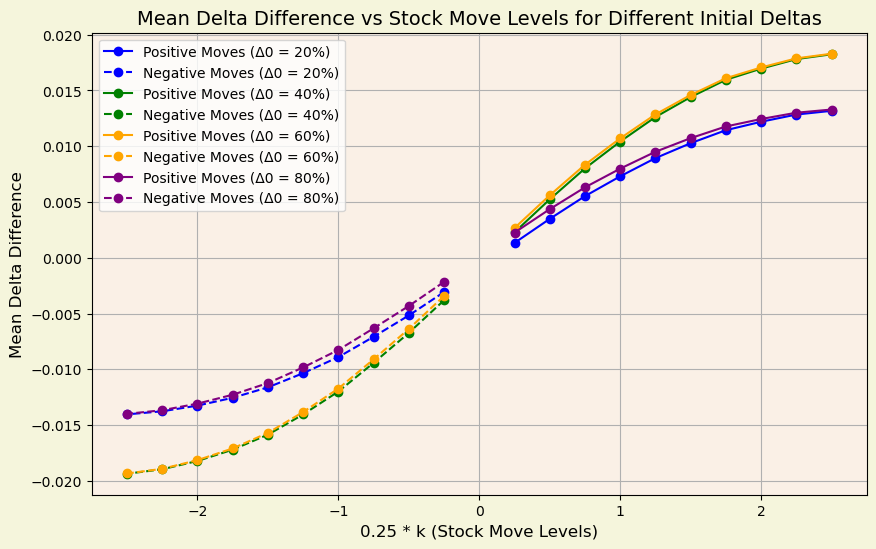

In [1]:
# Re-import necessary modules and reset parameters after environment reset
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
S0 = 100
K = 100
r = 0.05
sigma = 0.158
T = 1  # 1 year to maturity
delta_t = 1 / 252  # 1-day time step
N_MC = 10_000  # Number of Monte Carlo simulations
np.random.seed(42)
RN = np.random.randn(N_MC, 1)  # Random normal shocks
sigma_d = sigma * np.sqrt(delta_t)

# Function to calculate option delta
def opt_delta(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# Initial deltas to evaluate
initial_deltas = [0.2, 0.4, 0.6, 0.8]
colors = ['b', 'g', 'orange', 'purple']  # Colors for different lines
delta_diffs_results = []  # Store results for each initial delta

# Loop through each initial delta level
for initial_delta, color in zip(initial_deltas, colors):
    # Find the initial stock price corresponding to the target delta
    d1_value = norm.ppf(initial_delta)
    initial_S = K * np.exp(d1_value * sigma * np.sqrt(T) - (r + 0.5 * sigma**2) * T)
    
    # Simulate correct stock price moves from initial S
    S1 = initial_S * np.exp((r - 0.5 * sigma**2) * delta_t + sigma * np.sqrt(delta_t) * RN)
    D0 = opt_delta(initial_S, K, r, sigma, 252 / 252)  # Initial delta

    # Recalculate D1
    D1 = opt_delta(S1, K, r, sigma, 251 / 252)

    # Initialize arrays to store positive and negative delta differences
    delta_diffs_positive = []
    delta_diffs_negative = []

    # Compute delta differences for each k
    for k in range(1, 11):
        positive_threshold = initial_S + 0.25 * k * sigma_d * initial_S
        negative_threshold = initial_S - 0.25 * k * sigma_d * initial_S
        
        # Positive moves
        mask_positive = (S1 > initial_S) & (S1 <= positive_threshold)
        delta_diff_pos_k = np.nanmean(np.where(mask_positive, D1, np.NaN) - D0)
        delta_diffs_positive.append(delta_diff_pos_k)
        
        # Negative moves
        mask_negative = (S1 < initial_S) & (S1 >= negative_threshold)
        delta_diff_neg_k = np.nanmean(np.where(mask_negative, D1, np.NaN) - D0)
        delta_diffs_negative.append(delta_diff_neg_k)
    
    # Store results for plotting
    delta_diffs_results.append((delta_diffs_positive, delta_diffs_negative, initial_delta, color))

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F5F5DC')  # Light beige background
ax.set_facecolor('#FAF0E6')  # Lighter beige for the plot area

# Plot for each initial delta level
for pos_diffs, neg_diffs, initial_delta, color in delta_diffs_results:
    ax.plot(0.25 * np.arange(1, 11), pos_diffs, marker='o', linestyle='-', color=color, label=f'Positive Moves (Δ0 = {int(initial_delta*100)}%)')
    ax.plot(-0.25 * np.arange(1, 11), neg_diffs, marker='o', linestyle='--', color=color, label=f'Negative Moves (Δ0 = {int(initial_delta*100)}%)')

# Labeling the plot
ax.set_xlabel('0.25 * k (Stock Move Levels)', fontsize=12)
ax.set_ylabel('Mean Delta Difference', fontsize=12)
ax.set_title('Mean Delta Difference vs Stock Move Levels for Different Initial Deltas', fontsize=14)

# Customizing the grid and legend
ax.grid(True)
ax.legend(fontsize=10)

# Display the plot
plt.show()


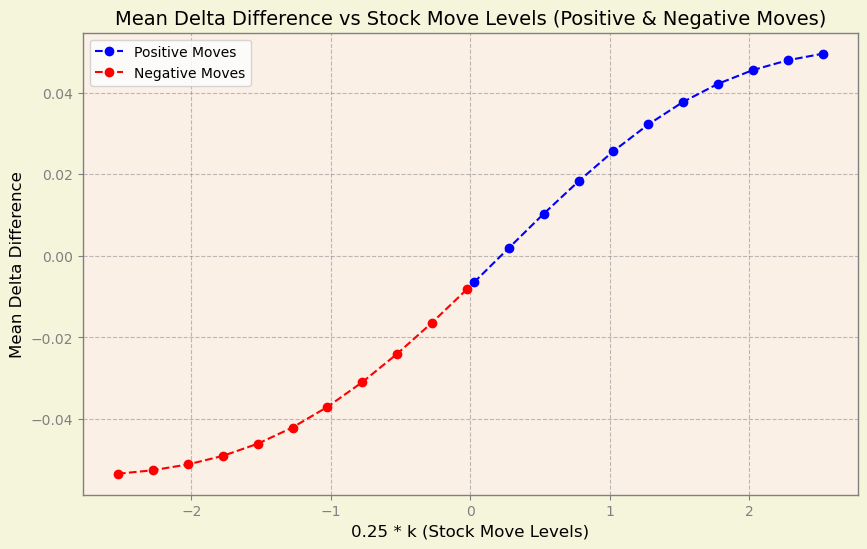

In [54]:
k_values = np.arange(0.1, 11) 
# Compute delta differences for both positive and negative stock price moves
delta_diffs_positive = []
delta_diffs_negative = []

for k in k_values:
    # Define upper and lower bounds for positive and negative moves
    positive_threshold = S0 + 0.25 * k * sigma_d * S0
    negative_threshold = S0 - 0.25 * k * sigma_d * S0
    
    # Mask for positive moves
    mask_positive = (S1 > S0) & (S1 <= positive_threshold)
    delta_diff_pos_k = np.nanmean(np.where(mask_positive, D1, np.NaN) - D0)
    delta_diffs_positive.append(delta_diff_pos_k)
    
    # Mask for negative moves
    mask_negative = (S1 < S0) & (S1 >= negative_threshold)
    delta_diff_neg_k = np.nanmean(np.where(mask_negative, D1, np.NaN) - D0)
    delta_diffs_negative.append(delta_diff_neg_k)

# Plot the delta differences for both positive and negative moves
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F5F5DC')  # Light beige background
ax.set_facecolor('#FAF0E6')  # Lighter beige for the plot area

# Plotting positive and negative delta differences
ax.plot(0.25 * k_values, delta_diffs_positive, marker='o', linestyle='--', color='b', label='Positive Moves')
ax.plot(-0.25 * k_values, delta_diffs_negative, marker='o', linestyle='--', color='r', label='Negative Moves')

# Labeling the plot
ax.set_xlabel('0.25 * k (Stock Move Levels)', fontsize=12)
ax.set_ylabel('Mean Delta Difference', fontsize=12)
ax.set_title('Mean Delta Difference vs Stock Move Levels (Positive & Negative Moves)', fontsize=14)

# Customizing the grid and legend
ax.grid(True)
ax.legend(fontsize=10)

# Display the plot
plt.show()


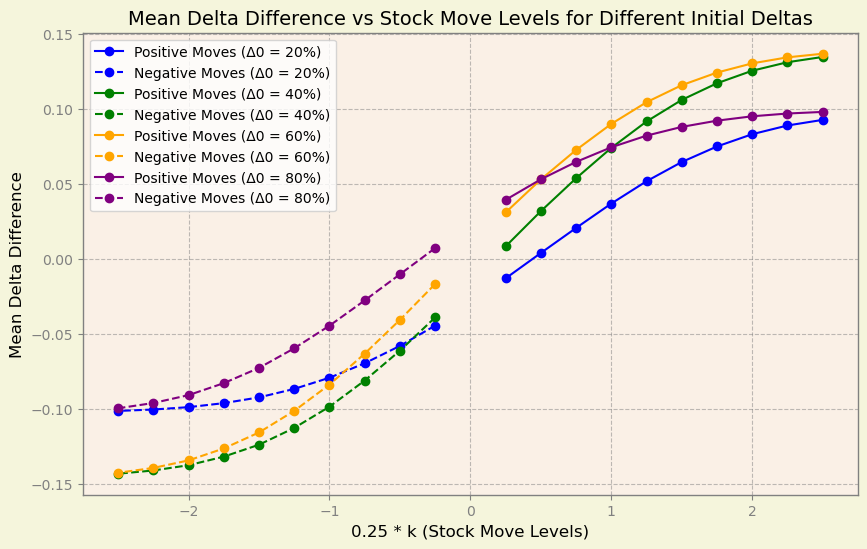

In [ ]:
# Simulate options DDelta
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
S0 = 100
K = 105
r = 0.05
sigma = 0.2
T = 5 / 252  # 5 days to maturity
delta_t = 1 / 252  # 1-day time step
N_MC = 100_000  # Number of Monte Carlo simulations
np.random.seed(42)
RN = np.random.randn(N_MC, 1)  # Random normal shocks
sigma_d = sigma * np.sqrt(delta_t)

# Function to calculate option delta
def opt_delta(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# Initial deltas to evaluate
initial_deltas = [0.2, 0.4, 0.6, 0.8]
colors = ['b', 'g', 'orange', 'purple']  # Colors for different lines
delta_diffs_results = []  # Store results for each initial delta

# Loop through each initial delta level
for initial_delta, color in zip(initial_deltas, colors):
    # Find the initial stock price corresponding to the target delta
    d1_value = norm.ppf(initial_delta)
    initial_S = K * np.exp(d1_value * sigma * np.sqrt(T) - (r + 0.5 * sigma**2) * T)
    
    # Simulate correct stock price moves from initial S
    S1 = initial_S * np.exp((r - 0.5 * sigma**2) * delta_t + sigma * np.sqrt(delta_t) * RN)
    D0 = opt_delta(initial_S, K, r, sigma, T)  # Initial delta

    # Recalculate D1
    D1 = opt_delta(S1, K, r, sigma, - 1.0 / 252 + T)

    # Initialize arrays to store positive and negative delta differences
    delta_diffs_positive = []
    delta_diffs_negative = []

    # Compute delta differences for each k
    for k in np.arange(1, 11):
        positive_threshold = initial_S + 0.25 * k * sigma_d * initial_S
        negative_threshold = initial_S - 0.25 * k * sigma_d * initial_S
        
        # Positive moves
        mask_positive = (S1 > initial_S) & (S1 <= positive_threshold)
        delta_diff_pos_k = np.nanmean(np.where(mask_positive, D1, np.NaN) - D0)
        delta_diffs_positive.append(delta_diff_pos_k)
        
        # Negative moves
        mask_negative = (S1 < initial_S) & (S1 >= negative_threshold)
        delta_diff_neg_k = np.nanmean(np.where(mask_negative, D1, np.NaN) - D0)
        delta_diffs_negative.append(delta_diff_neg_k)
    
    # Store results for plotting
    delta_diffs_results.append((delta_diffs_positive, delta_diffs_negative, initial_delta, color))

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F5F5DC')  # Light beige background
ax.set_facecolor('#FAF0E6')  # Lighter beige for the plot area

# Plot for each initial delta level
for pos_diffs, neg_diffs, initial_delta, color in delta_diffs_results:
    ax.plot(0.25 * np.arange(1, 11), pos_diffs, marker='o', linestyle='-', color=color, label=f'Positive Moves (Δ0 = {int(initial_delta*100)}%)')
    ax.plot(-0.25 * np.arange(1, 11), neg_diffs, marker='o', linestyle='--', color=color, label=f'Negative Moves (Δ0 = {int(initial_delta*100)}%)')

# Labeling the plot
ax.set_xlabel('0.25 * k (Stock Move Levels)', fontsize=12)
ax.set_ylabel('Mean Delta Difference', fontsize=12)
ax.set_title('Mean Delta Difference vs Stock Move Levels for Different Initial Deltas', fontsize=14)

# Customizing the grid and legend
ax.grid(True)
ax.legend(fontsize=10)

# Display the plot
plt.show()


To model the change in delta mathematically, you can use a **theoretical approach** based on the **Black-Scholes option pricing model**. Delta itself, as you know, is the sensitivity of the option price to changes in the underlying stock price, and it is given by:

\[
\Delta = N(d_1)
\]

Where \( N(d_1) \) is the **cumulative distribution function (CDF)** of the standard normal distribution, and \( d_1 \) is defined as:

\[
d_1 = \frac{\ln(S / K) + (r + \frac{\sigma^2}{2}) T}{\sigma \sqrt{T}}
\]

### **Steps to Model Change in Delta Under a Large Stock Move**

1. **Delta Sensitivity to Stock Price (Change in Delta)**:  
   The change in delta can be captured by the **Gamma** (\(\Gamma\)), which is the second derivative of the option price with respect to the stock price:

\[
\Gamma = \frac{\partial \Delta}{\partial S} = \frac{N'(d_1)}{S \sigma \sqrt{T}}
\]

Where:
- \( N'(d_1) \) is the **standard normal probability density function (PDF)** evaluated at \( d_1 \),
- \( S \) is the stock price,
- \( \sigma \) is the volatility,
- \( T \) is the time to maturity.

The **change in delta** for a large stock price move (\( \Delta S \)) can be approximated using **Gamma** as:

\[
\Delta \Delta = \Gamma \cdot \Delta S
\]

Thus, the change in delta (\( \Delta \Delta \)) for a **small price change** \( \Delta S \) can be approximated as:

\[
\Delta \Delta \approx \frac{N'(d_1)}{S \sigma \sqrt{T}} \cdot \Delta S
\]

Where \( \Delta S \) is the **absolute change** in the stock price from the initial value \( S_0 \) to the new value \( S_1 \).

2. **Magnitude of the Stock Move**:  
   You condition the magnitude of the delta change on how large the stock move is. The magnitude of stock moves can be described as the **proportional change** in the stock price. If we condition on the magnitude \( k \) of stock moves (as in your experiments), we can express \( S_1 \) as:

\[
S_1 = S_0 \pm k \cdot \sigma_d \cdot S_0
\]

Where \( \sigma_d \) is the daily volatility, and \( k \) is a factor that scales the stock move. For **positive** and **negative** moves, \( k \) defines the size of the change in terms of volatility.

3. **Change in Delta as a Function of Stock Move**:  
   Given the stock move magnitude \( k \), we can model the **change in delta** as:

\[
\Delta \Delta = \Gamma \cdot (S_1 - S_0) = \frac{N'(d_1)}{S_0 \sigma \sqrt{T}} \cdot (k \cdot \sigma_d \cdot S_0)
\]

This simplifies to:

\[
\Delta \Delta = k \cdot \frac{N'(d_1)}{\sigma \sqrt{T}} \cdot \sigma_d
\]

Thus, for a large stock move, you have the theoretical formula for the change in delta conditioned on the **magnitude of the stock move** \( k \).

### **Steps for Theoretical Approach to Calculate Delta Change:**

1. **Find \( d_1 \) for the initial stock price \( S_0 \).**  
2. **Compute Gamma \( \Gamma \).**  
3. **Calculate the change in delta using the formula:**  
   \[
   \Delta \Delta = k \cdot \frac{N'(d_1)}{\sigma \sqrt{T}} \cdot \sigma_d
   \]
   for different values of \( k \) (the magnitude of stock moves).

### **Summary**
- **Gamma** (\( \Gamma \)) is used to model the change in delta, which is sensitive to large stock moves.  
- The change in delta is conditioned on the magnitude of the stock move, \( k \), which scales the price change relative to volatility.

This formulation provides a clean and mathematically robust way to model the change in delta under large stock moves, and it can be applied analytically without resorting to simulations.


To model the change in delta mathematically, you can use a **theoretical approach** based on the **Black-Scholes option pricing model**. Delta itself, as you know, is the sensitivity of the option price to changes in the underlying stock price, and it is given by:

$$
\Delta = N(d_1)
$$

Where $N(d_1)$ is the **cumulative distribution function (CDF)** of the standard normal distribution, and $d_1$ is defined as:

$$
d_1 = \frac{\ln(S / K) + \left(r + \frac{\sigma^2}{2}\right) T}{\sigma \sqrt{T}}
$$

---

### **Steps to Model Change in Delta Under a Large Stock Move**

1. **Delta Sensitivity to Stock Price (Change in Delta)**  
   The change in delta can be captured by the **Gamma** ($\Gamma$), which is the second derivative of the option price with respect to the stock price:

   $$
   \Gamma = \frac{\partial \Delta}{\partial S} = \frac{N'(d_1)}{S \sigma \sqrt{T}}
   $$

   Where:  
   - $N'(d_1)$ is the **standard normal probability density function (PDF)** evaluated at $d_1$,  
   - $S$ is the stock price,  
   - $\sigma$ is the volatility,  
   - $T$ is the time to maturity.  

   The **change in delta** for a large stock price move ($\Delta S$) can be approximated using **Gamma** as:

   $$
   \Delta \Delta = \Gamma \cdot \Delta S
   $$

   Thus, the change in delta ($\Delta \Delta$) for a **small price change** $\Delta S$ can be approximated as:

   $$
   \Delta \Delta \approx \frac{N'(d_1)}{S \sigma \sqrt{T}} \cdot \Delta S
   $$

   Where $\Delta S$ is the **absolute change** in the stock price from the initial value $S_0$ to the new value $S_1$.

2. **Magnitude of the Stock Move**  
   The magnitude of stock moves can be described as the **proportional change** in the stock price. If we condition on the magnitude $k$ of stock moves, we can express $S_1$ as:

   $$
   S_1 = S_0 \pm k \cdot \sigma_d \cdot S_0
   $$

   Where:  
   - $\sigma_d$ is the daily volatility,  
   - $k$ is a factor that scales the stock move (e.g., $k = 1, 2, 3$).  

3. **Change in Delta as a Function of Stock Move**  
   Given the stock move magnitude $k$, the **change in delta** simplifies to:

   $$
   \Delta \Delta = \Gamma \cdot (S_1 - S_0) = \frac{N'(d_1)}{S_0 \sigma \sqrt{T}} \cdot (k \cdot \sigma_d \cdot S_0)
   $$

   $$
   \Delta \Delta = k \cdot \frac{N'(d_1)}{\sigma \sqrt{T}} \cdot \sigma_d
   $$

---

### **Steps for Theoretical Approach to Calculate Delta Change**

1. **Find $d_1$ for the initial stock price $S_0$**  
   $$
   d_1 = \frac{\ln(S_0 / K) + \left(r + \frac{\sigma^2}{2}\right) T}{\sigma \sqrt{T}}
   $$

2. **Compute Gamma $\Gamma$**  
   $$
   \Gamma = \frac{N'(d_1)}{S_0 \sigma \sqrt{T}}
   $$

3. **Calculate the change in delta**  
   $$
   \Delta \Delta = k \cdot \frac{N'(d_1)}{\sigma \sqrt{T}} \cdot \sigma_d
   $$
   for different values of $k$.

---

### **Summary**
- **Gamma** ($\Gamma$) models the change in delta and is sensitive to large stock moves.  
- The change in delta is conditioned on the magnitude $k$, which scales the price change relative to volatility.  

This formulation provides a clean and mathematically robust way to model delta changes under large stock moves without simulations.

$$
   S_1 = S_0 \pm k \cdot \sigma_d \cdot S_0
$$

In [ ]:
## Mathematical Evaluation

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Parameters
S0 = 100
K = 105
r = 0.05
sigma = 0.2
T = 5 / 252  # 5 days to maturity
delta_t = 1 / 252  # 1-day time step
N_MC = 100_000  # Number of Monte Carlo simulations

# Function to calculate d1 for given S
def d1(S, K, r, sigma, T):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

# Function to calculate the change in Delta
def delta_change(S0, K, r, sigma, T, N_MC, S_max_factor=1.5):
    # Generate N_MC random paths for stock prices using geometric Brownian motion
    dt = delta_t
    S_paths = np.zeros(N_MC)
    S_paths[:] = S0  # Initialize all paths with S0

    # Simulate stock paths
    for i in range(N_MC):
        # Simulate a random walk for the stock price
        dW = np.random.normal(0, np.sqrt(dt), size=int(T / delta_t))
        log_returns = (r - 0.5 * sigma**2) * delta_t + sigma * dW
        S_paths[i] *= np.exp(np.sum(log_returns))

    # Compute the change in Delta for each simulated stock price
    delta_initial = norm.cdf(d1(S0, K, r, sigma, T))
    delta_change_vals = np.zeros(N_MC)

    for i in range(N_MC):
        delta_new = norm.cdf(d1(S_paths[i], K, r, sigma, T))
        delta_change_vals[i] = delta_new - delta_initial

    # Return the average change in Delta
    return np.mean(delta_change_vals)

# Run the Monte Carlo simulation to evaluate the change in Delta
delta_change_result = delta_change(S0, K, r, sigma, T, N_MC)

# Output the result
delta_change_result


In [11]:
# working on this code 2/5, fixing reporting of the units in the daily volatility units...

import numpy as np
from scipy.stats import norm
from scipy.integrate import quad

# Parameters
S0 = 100
K = 105
r = 0.05
sigma = 0.2
T = 5 / 252  # 5 days to maturity

# Define the PDF of the stock price under the Black-Scholes model
def stock_price_pdf(S_T, S0, K, r, sigma, T):
    return (1 / (S_T * sigma * np.sqrt(2 * np.pi * T))) * np.exp(
        -((np.log(S_T / S0) - (r - 0.5 * sigma**2) * T) ** 2) / (2 * sigma**2 * T)
    )

# Define the d1 formula
def d1(S_T, K, r, sigma, T):
    return (np.log(S_T / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

# Define the change in Delta integrand
def integrand(S_T, S0, K, r, sigma, T):
    delta_initial = norm.cdf(d1(S0, K, r, sigma, T))
    delta_new = norm.cdf(d1(S_T, K, r, sigma, T))
    pdf_value = stock_price_pdf(S_T, S0, K, r, sigma, T)
    return (delta_new - delta_initial) * pdf_value

# Define the function to compute the integral
def compute_delta_change_integral(S0, K, r, sigma, T, k_vals):
    results = {}
    for k in k_vals:
        upper_bound = S0 + k * sigma * S0 / np.sqrt(252)
        integral, _ = quad(integrand, S0, upper_bound, args=(S0, K, r, sigma, T))
        results[k] = integral
    return results

# Define k values
k_vals = np.arange(0.05, 5.05, 0.25)

# Compute the integrals for each k
delta_change_integrals = compute_delta_change_integral(S0, K, r, sigma, T, k_vals)

# Display the results
delta_change_integrals


{0.05: 9.775903967507132e-06,
 0.3: 0.00037236405523192074,
 0.55: 0.0013149438547362194,
 0.8: 0.002901457533559135,
 1.05: 0.005173040911087355,
 1.3: 0.008142773514743306,
 1.55: 0.011792311082641314,
 1.8: 0.016070936697836692,
 2.05: 0.020897298952787798,
 2.3: 0.02616377926880919,
 2.55: 0.031743098830321774,
 2.8: 0.0374964944364584,
 3.05: 0.04328260884812929,
 3.3: 0.048966183118459024,
 3.55: 0.05442571016664302,
 3.8: 0.059559391109280845,
 4.05: 0.06428899115507104,
 4.3: 0.06856147366631386,
 4.55: 0.07234855362440806,
 4.8: 0.075644518911494}

In [33]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad

def d1(S, K, r, sigma, T):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def integrand(S, S0, K, r, sigma, T):
    delta_initial = norm.cdf(d1(S0, K, r, sigma, T))
    delta_new = norm.cdf(d1(S, K, r, sigma, T))
    pdf = 0.0
    if S > 0:
        pdf = (1.0 / (S * sigma * np.sqrt(2 * np.pi * T))) * np.exp(
            -((np.log(S / S0) - (r - 0.5 * sigma**2) * T) ** 2) / (2 * sigma**2 * T)
        )
    return (delta_new - delta_initial) * pdf

def compute_delta_change_integral(S0, K, r, sigma, T, k_vals):
    """
    Integrates from S0 to S0 + k*(sigma/sqrt(252))*S0, 
    capturing a one-day move scaled by k.
    """
    results = {}
    for k in k_vals:
        upper_bound = S0 + k * sigma * S0 / np.sqrt(252)
        S = min(S0, upper_bound)
        Su = max(upper_bound, S0)
        val, _ = quad(integrand, S, Su, args=(S0, K, r, sigma, T))
        results[k] = val
    return results

# Example usage
if __name__ == "__main__":
    S0, K, r, sigma = 100, 99.5, 0.05, 0.158
    T = 5 / 252  # ~5 trading days
    k_values = np.concatenate([-np.arange(0.05, 5.05, 0.25), np.arange(0.05, 5.05, 0.25)])

    # Initial delta at S0
    init_delta = norm.cdf(d1(S0, K, r, sigma, T))

    # Delta after exactly one daily standard deviation move
    S_one_day = S0 + sigma * S0 / np.sqrt(252)
    one_day_delta = norm.cdf(d1(S_one_day, K, r, sigma, T))
    one_day_delta_change = one_day_delta - init_delta

    # Integrate the delta change over [S0, S0 + k*(sigma/sqrt(252))*S0]
    integrated_results = compute_delta_change_integral(S0, K, r, sigma, T, k_values)

    print("Initial stock price for the delta:", S0)
    print("Initial delta at S0:", init_delta)
    print("Delta change for 1-day vol move:", one_day_delta_change)
    print("\nDelta change integral results:")
    for k, val in integrated_results.items():
        print(f"k={k:.2f}, integral={val:.5f}")


Initial stock price for the delta: 100
Initial delta at S0: 0.6106173032017198
Delta change for 1-day vol move: 0.1554421555108022

Delta change integral results:
k=-0.05, integral=-0.00004
k=-0.30, integral=-0.00139
k=-0.55, integral=-0.00464
k=-0.80, integral=-0.00970
k=-1.05, integral=-0.01637
k=-1.30, integral=-0.02439
k=-1.55, integral=-0.03343
k=-1.80, integral=-0.04315
k=-2.05, integral=-0.05320
k=-2.30, integral=-0.06323
k=-2.55, integral=-0.07295
k=-2.80, integral=-0.08211
k=-3.05, integral=-0.09053
k=-3.30, integral=-0.09809
k=-3.55, integral=-0.10472
k=-3.80, integral=-0.11042
k=-4.05, integral=-0.11521
k=-4.30, integral=-0.11917
k=-4.55, integral=-0.12238
k=-4.80, integral=-0.12493
k=0.05, integral=0.00004
k=0.30, integral=0.00135
k=0.55, integral=0.00443
k=0.80, integral=0.00908
k=1.05, integral=0.01504
k=1.30, integral=0.02201
k=1.55, integral=0.02968
k=1.80, integral=0.03773
k=2.05, integral=0.04588
k=2.30, integral=0.05389
k=2.55, integral=0.06153
k=2.80, integral=0.068

<Axes: xlabel='k'>

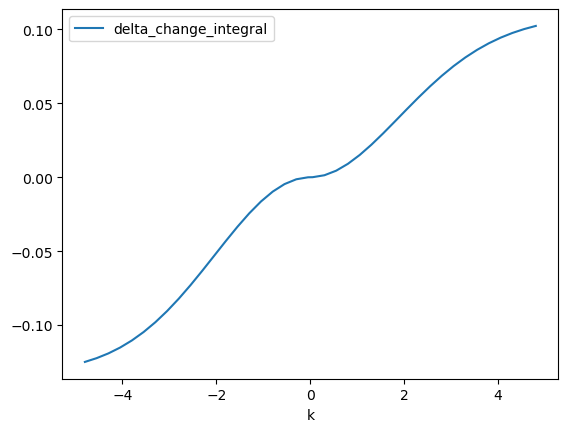

In [34]:
import pandas as pd
res_df = pd.DataFrame(list(integrated_results.items()), columns=["k", "delta_change_integral"])

res_df.set_index('k').sort_index().plot()

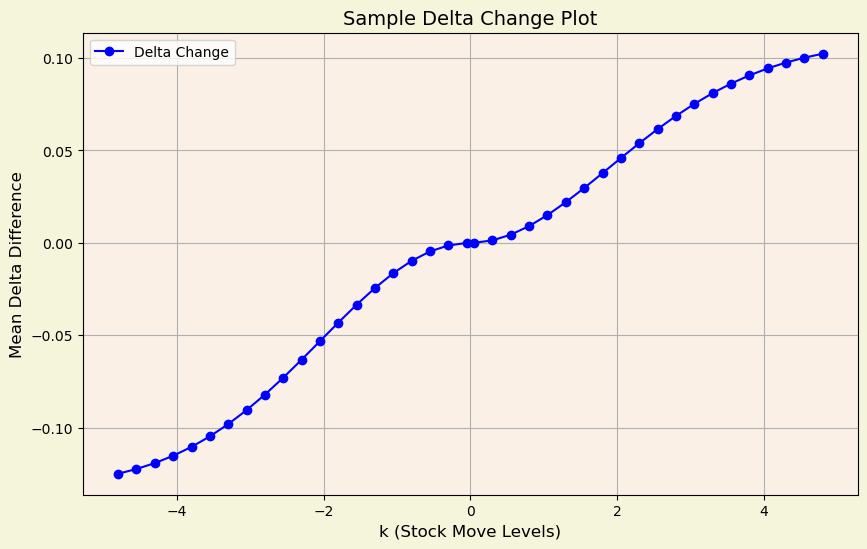

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_delta_change_dataframe(df, title="Delta Change vs. k"):
    """
    Plots the given pandas DataFrame (with columns 'k' and 'delta_change_integral')
    using a style similar to the provided example.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#F5F5DC')
    ax.set_facecolor('#FAF0E6')
    
    # Single-line plot of k vs. delta_change_integral
    ax.plot(
        df['k'],
        df['delta_change_integral'],
        marker='o',
        linestyle='-',
        color='b',
        label='Delta Change'
    )

    ax.set_xlabel('k (Stock Move Levels)', fontsize=12)
    ax.set_ylabel('Mean Delta Difference', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True)
    ax.legend(fontsize=10)
    plt.show()


# Example usage:
if __name__ == "__main__":
    # Sample data
    integrated_results = {
        0.05: 0.00285,
        0.30: 0.07518,
        0.55: 0.08962,
        0.80: 0.08972,
        1.05: 0.08972
    }

    # Convert dictionary to DataFrame
    df = pd.DataFrame(list(integrated_results.items()), columns=["k", "delta_change_integral"])

    # Plot using the custom function
    plot_delta_change_dataframe(df=res_df.sort_values('k'), title="Sample Delta Change Plot")


Initial log-moneyness: 0.005716306996109099
Initial delta: 0.5995604069180527
Computed Integral Results:
 {0.05: 3.8443745809785055e-05, 0.3: 0.0013610470743071756, 0.55: 0.0044629343417703585, 0.8: 0.009140739920686907, 1.05: 0.015131441528565532, 1.3: 0.02213412965362604, 1.55: 0.02983258342460889, 1.8: 0.03791637711130738, 2.05: 0.04609871402243224, 2.3: 0.054129822356308976, 2.55: 0.061805428370578744, 2.8: 0.06897043889155406, 3.05: 0.07551844228332526, 3.3: 0.08138793776379706, 3.55: 0.08655632686461134, 3.8: 0.09103267475903477, 4.05: 0.09485011561011535, 4.3: 0.0980585816484004, 4.55: 0.10071832226292667, 4.8: 0.10289447883278978}


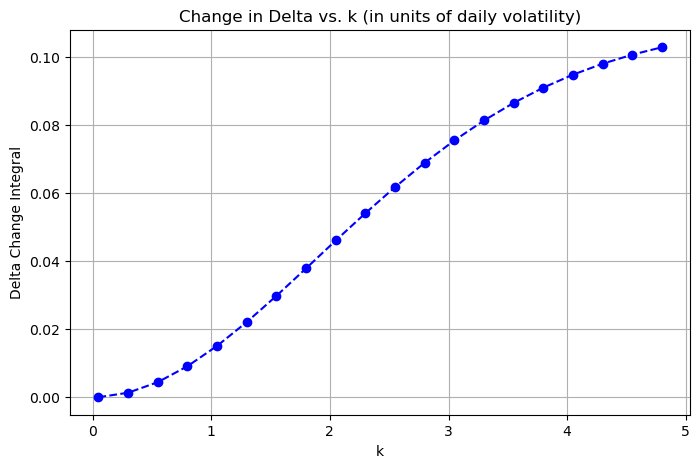

In [3]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
import matplotlib.pyplot as plt

class DeltaChangeIntegrator:
    def __init__(self, S0, K, r, sigma, T):
        """
        Initializes the DeltaChangeIntegrator with parameters:
        :param S0: initial stock price
        :param K: strike price
        :param r: risk-free interest rate (annual)
        :param sigma: volatility (annual)
        :param T: time to maturity in years
        """
        self.S0 = S0
        self.K = K
        self.r = r
        self.sigma = sigma  # annual volatility
        self.T = T

        # Convert annualized sigma to daily sigma for integration bounds
        self.daily_sigma = self.sigma / np.sqrt(252)

    def inital_log_moneyness(self):
        """
        Return the initial log-moneyness for this option, typically ln(S0/K).
        """
        return np.log(self.S0 / self.K)

    def initial_delta(self):
        """
        Return the initial Delta for this option (European call).
        """
        return norm.cdf(self.d1(self.S0, self.K, self.r, self.sigma, self.T))

    @staticmethod
    def d1(S, K, r, sigma, T):
        """
        Computes d1 for the Black-Scholes formula given a stock price S, strike K,
        risk-free rate r, volatility sigma, and time to maturity T.
        """
        return (
            np.log(S / K) + (r + 0.5 * sigma**2) * T
        ) / (sigma * np.sqrt(T))

    @staticmethod
    def stock_price_pdf(S, S0, r, sigma, T):
        """
        PDF of the lognormal distribution for S under the Black-Scholes model,
        given initial price S0, rate r, volatility sigma, time T.
        """
        # Avoid negative or zero prices that can break log()
        if S <= 0:
            return 0.0

        return (1.0 / (S * sigma * np.sqrt(2 * np.pi * T))) * np.exp(
            -((np.log(S / S0) - (r - 0.5 * sigma**2) * T) ** 2) / (2 * sigma**2 * T)
        )

    def integrand(self, S):
        """
        The integrand that computes (Delta(S) - Delta(S0)) * PDF(S).
        """
        # Compute the initial and new delta
        delta_initial = norm.cdf(self.d1(self.S0, self.K, self.r, self.sigma, self.T))
        delta_new = norm.cdf(self.d1(S, self.K, self.r, self.sigma, self.T))

        # PDF of S
        pdf_value = self.stock_price_pdf(S, self.S0, self.r, self.sigma, self.T)

        return (delta_new - delta_initial) * pdf_value

    def compute_delta_change_integral(self, k_vals):
        """
        Numerically integrate the change in Delta from S0 to S0 * (1 + k * daily_sigma),
        for each k in k_vals. Returns a dictionary {k: integral_value}.
        """
        results = {}
        for k in k_vals:
            # Define upper bound using daily volatility
            upper_bound = self.S0 * (1 + k * self.daily_sigma)

            integral_val, _ = quad(self.integrand, self.S0, upper_bound)
            results[k] = integral_val

        return results

    def plot_results(self, delta_change_dict):
        """
        Plots the integral results (Delta change) as a function of k.
        """
        ks = sorted(delta_change_dict.keys())
        vals = [delta_change_dict[k] for k in ks]

        plt.figure(figsize=(8, 5))
        plt.plot(ks, vals, marker='o', linestyle='--', color='b')
        plt.title("Change in Delta vs. k (in units of daily volatility)")
        plt.xlabel("k")
        plt.ylabel("Delta Change Integral")
        plt.grid(True)
        plt.show()


if __name__ == "__main__":
    # Example usage:
    S0 = 100
    K = 99.43
    r = 0.05
    sigma = 0.2
    T = 5 / 252  # 5 days to maturity

    # k values that scale daily volatility
    k_values = np.arange(0.05, 5.05, 0.25)

    # Instantiate the integrator class
    integrator = DeltaChangeIntegrator(S0, K, r, sigma, T)

    # Print the initial log-moneyness and delta
    print("Initial log-moneyness:", integrator.inital_log_moneyness())
    print("Initial delta:", integrator.initial_delta())

    # Compute the integral results for each k
    results = integrator.compute_delta_change_integral(k_values)
    print("Computed Integral Results:\n", results)

    # Plot the results
    integrator.plot_results(results)


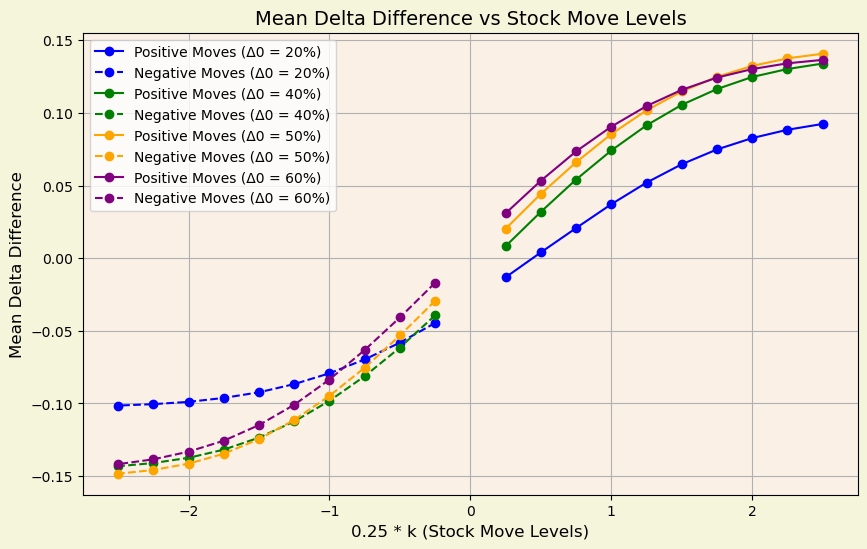

In [7]:
# Cursor by simulation
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import List, Tuple

class OptionDeltaSimulator:
    def __init__(self, S0: float, K: float, r: float, sigma: float, T: float, delta_t: float):
        """
        Initialize the Option Delta Simulator.
        
        Parameters:
        - S0: Initial stock price
        - K: Strike price
        - r: Risk-free rate
        - sigma: Volatility
        - T: Time to maturity (in years)
        - delta_t: Time step for simulation (in years)
        """
        self.S0 = S0
        self.K = K
        self.r = r
        self.sigma = sigma
        self.T = T
        self.delta_t = delta_t
        self.sigma_d = sigma * np.sqrt(delta_t)
    
    def _calculate_d1(self, S: float, t: float) -> float:
        """Calculate d1 term in Black-Scholes formula."""
        return (np.log(S / self.K) + (self.r + 0.5 * self.sigma**2) * t) / (self.sigma * np.sqrt(t))
    
    def _calculate_delta(self, S: float, t: float) -> float:
        """Calculate option delta."""
        return norm.cdf(self._calculate_d1(S, t))
    
    def simulate(self, initial_delta: float, N_MC: int = 100_000) -> Tuple[List[float], List[float]]:
        """
        Simulate delta changes for a given initial delta.
        
        Parameters:
        - initial_delta: Target initial delta (between 0 and 1)
        - N_MC: Number of Monte Carlo simulations
        
        Returns:
        - Tuple of (positive_delta_diffs, negative_delta_diffs)
        """
        # Find initial stock price for target delta
        d1_value = norm.ppf(initial_delta)
        initial_S = self.K * np.exp(d1_value * self.sigma * np.sqrt(self.T) - 
                                  (self.r + 0.5 * self.sigma**2) * self.T)
        
        # Generate random normal shocks
        RN = np.random.randn(N_MC, 1)
        
        # Simulate stock price moves
        S1 = initial_S * np.exp((self.r - 0.5 * self.sigma**2) * self.delta_t + 
                               self.sigma * np.sqrt(self.delta_t) * RN)
        
        # Calculate initial and final deltas
        D0 = self._calculate_delta(initial_S, self.T)
        D1 = self._calculate_delta(S1, self.T - self.delta_t)
        
        delta_diffs_positive = []
        delta_diffs_negative = []
        
        # Calculate delta differences for different move sizes
        for k in np.arange(1, 11):
            pos_threshold = initial_S + 0.25 * k * self.sigma_d * initial_S
            neg_threshold = initial_S - 0.25 * k * self.sigma_d * initial_S
            
            # Positive moves
            mask_pos = (S1 > initial_S) & (S1 <= pos_threshold)
            delta_diff_pos = np.nanmean(np.where(mask_pos, D1, np.NaN) - D0)
            delta_diffs_positive.append(delta_diff_pos)
            
            # Negative moves
            mask_neg = (S1 < initial_S) & (S1 >= neg_threshold)
            delta_diff_neg = np.nanmean(np.where(mask_neg, D1, np.NaN) - D0)
            delta_diffs_negative.append(delta_diff_neg)
            
        return delta_diffs_positive, delta_diffs_negative
    
    def plot(self, results: List[Tuple[List[float], List[float], float]], 
            title: str = "Mean Delta Difference vs Stock Move Levels"):
        """
        Plot delta differences for multiple initial deltas.
        
        Parameters:
        - results: List of tuples (positive_diffs, negative_diffs, initial_delta)
        - title: Plot title
        """
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor('#F5F5DC')
        ax.set_facecolor('#FAF0E6')
        
        colors = ['b', 'g', 'orange', 'purple']
        k_values = np.arange(1, 11)
        
        for (pos_diffs, neg_diffs, initial_delta), color in zip(results, colors):
            ax.plot(0.25 * k_values, pos_diffs, marker='o', linestyle='-', 
                   color=color, label=f'Positive Moves (Δ0 = {int(initial_delta*100)}%)')
            ax.plot(-0.25 * k_values, neg_diffs, marker='o', linestyle='--', 
                   color=color, label=f'Negative Moves (Δ0 = {int(initial_delta*100)}%)')
        
        ax.set_xlabel('0.25 * k (Stock Move Levels)', fontsize=12)
        ax.set_ylabel('Mean Delta Difference', fontsize=12)
        ax.set_title(title, fontsize=14)
        ax.grid(True)
        ax.legend(fontsize=10)
        
        plt.show()

# Example usage:
if __name__ == "__main__":
    simulator = OptionDeltaSimulator(
        S0=100, K=99.5, r=0.05, sigma=0.2, 
        T=5/252, delta_t=1/252
    )
    
    results = []
    for delta in [0.2, 0.4, 0.5, 0.6, 0.8]:
        pos_diffs, neg_diffs = simulator.simulate(delta)
        results.append((pos_diffs, neg_diffs, delta))
    
    simulator.plot(results)